## 1. Dataset Info

In [5]:
import pandas as pd

df = pd.read_csv("../data/creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
df.shape

(284807, 31)

In [7]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [8]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

## 2. Baseline (No Leakage)

In [6]:
# Taking a subset for faster computation
df_small = df.sample(n=30000, random_state=42)

df_small.shape

(30000, 31)

In [7]:
df_sorted = df_small.sort_values(by="Time")

In [8]:
split_index = int(len(df_sorted) * 0.8)

train = df_sorted.iloc[:split_index]
test = df_sorted.iloc[split_index:]

X_train = train.drop(columns=["Class"])
y_train = train["Class"]

X_test = test.drop(columns=["Class"])
y_test = test["Class"]

print(X_train.shape, X_test.shape)

(24000, 30) (6000, 30)


In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),
    
    "Support Vector Machine": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="linear"))  
    ]),
    
    "Random Forest": Pipeline([
        ("model", RandomForestClassifier(random_state=42))
    ])
}

In [10]:
results = []

for name, model in models.items():
    print(f"Training {name}...")
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)
results_df

Training Logistic Regression...
Training Support Vector Machine...
Training Random Forest...


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.999333,1.000000,0.555556,0.714286
1,Support Vector Machine,0.999167,0.833333,0.555556,0.666667
2,Random Forest,0.999000,1.000000,0.333333,0.500000


## 3. Target Leakage

In [11]:
df_leak = df_small.copy()

In [12]:
# -------------------------------
# Target Leakage Implementation
# -------------------------------

import numpy as np
import pandas as pd

# Creating a copy of the original dataset to ensure the baseline dataset remains unchanged
df_leak = df_small.copy()


# Step 2: Introduce target leakage
# Create a feature directly derived from the target variable
noise = np.random.normal(0, 0.01, size=len(df_leak))
df_leak["target_leak_feature"] = df_leak["Class"] + noise


df_leak_sorted = df_leak.sort_values(by="Time")

split_index = int(len(df_leak_sorted) * 0.8)

train_l = df_leak_sorted.iloc[:split_index]
test_l = df_leak_sorted.iloc[split_index:]


X_train_l = train_l.drop(columns=["Class"])
y_train_l = train_l["Class"]

X_test_l = test_l.drop(columns=["Class"])
y_test_l = test_l["Class"]


results_leak = []

for name, model in models.items():
    
    model.fit(X_train_l, y_train_l)
    
    y_pred_l = model.predict(X_test_l)
    
    accuracy = accuracy_score(y_test_l, y_pred_l)
    precision = precision_score(y_test_l, y_pred_l)
    recall = recall_score(y_test_l, y_pred_l)
    f1 = f1_score(y_test_l, y_pred_l)

    results_leak.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

results_leak_df = pd.DataFrame(results_leak)

results_leak_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Support Vector Machine,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0


## 4. Train-Test Contamination

In [13]:
# -----------------------------------------
# Train-Test Contamination Implementation
# -----------------------------------------

import pandas as pd
from sklearn.preprocessing import StandardScaler


# Creating a copy of the original dataset to ensure the baseline dataset remains unchanged
df_contam = df_small.copy()


X_contam = df_contam.drop(columns=["Class"])
y_contam = df_contam["Class"]


# Step 3: Introduce leakage through incorrect preprocessing
# The scaler is fitted on the entire dataset before splitting
# This allows information from the test set to influence training
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_contam)

X_scaled_df = pd.DataFrame(X_scaled, columns=X_contam.columns)

df_scaled = X_scaled_df.copy()
df_scaled["Class"] = y_contam.values


df_scaled_sorted = df_scaled.sort_values(by="Time")


split_index = int(len(df_scaled_sorted) * 0.8)

train_c = df_scaled_sorted.iloc[:split_index]
test_c = df_scaled_sorted.iloc[split_index:]

X_train_c = train_c.drop(columns=["Class"])
y_train_c = train_c["Class"]

X_test_c = test_c.drop(columns=["Class"])
y_test_c = test_c["Class"]

results_contam = []

for name, model in models.items():
    
    model.fit(X_train_c, y_train_c)
    
    y_pred_c = model.predict(X_test_c)
    
    accuracy = accuracy_score(y_test_c, y_pred_c)
    precision = precision_score(y_test_c, y_pred_c)
    recall = recall_score(y_test_c, y_pred_c)
    f1 = f1_score(y_test_c, y_pred_c)
    
    results_contam.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

results_contam_df = pd.DataFrame(results_contam)

results_contam_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.999333,1.000000,0.555556,0.714286
1,Support Vector Machine,0.999167,0.833333,0.555556,0.666667
2,Random Forest,0.999000,1.000000,0.333333,0.500000


## 5. Temporal Leakage

In [14]:
# -----------------------------------------
# Temporal Leakage Implementation
# -----------------------------------------

import pandas as pd
from sklearn.model_selection import train_test_split


# Creating a copy of the original dataset to ensure the baseline dataset remains unchanged
df_temp = df_small.copy()


X_temp = df_temp.drop(columns=["Class"])
y_temp = df_temp["Class"]


# Introduce temporal leakage through incorrect data splitting
# A random train-test split is used instead of a time-based split
# This ignores the chronological order of transactions and allows
# future information to be included in the training data
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_temp, y_temp,
    test_size=0.2,
    random_state=42,
    stratify=y_temp
)


results_temp = []

for name, model in models.items():

    model.fit(X_train_t, y_train_t)
    
    y_pred_t = model.predict(X_test_t)
    
    accuracy = accuracy_score(y_test_t, y_pred_t)
    precision = precision_score(y_test_t, y_pred_t)
    recall = recall_score(y_test_t, y_pred_t)
    f1 = f1_score(y_test_t, y_pred_t)
    
    results_temp.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

results_temp_df = pd.DataFrame(results_temp)

results_temp_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.998833,0.750000,0.333333,0.461538
1,Support Vector Machine,0.999000,0.714286,0.555556,0.625000
2,Random Forest,0.999167,0.833333,0.555556,0.666667


## 6. Heatmap

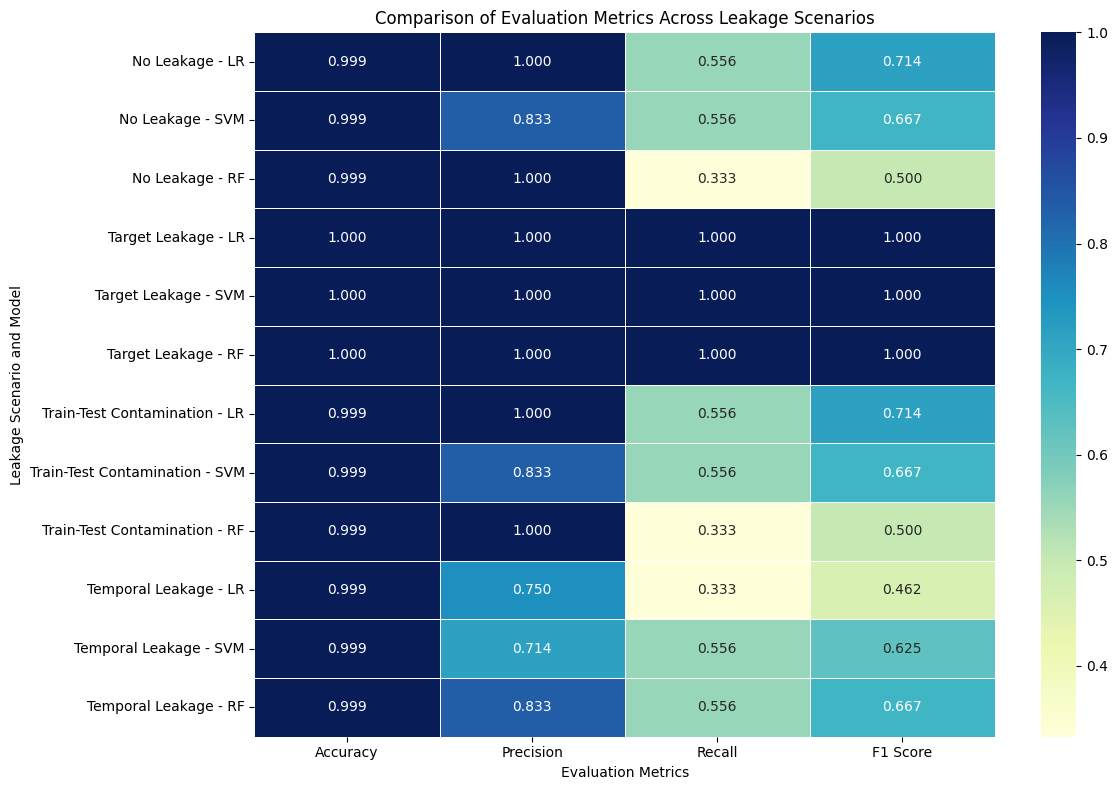

In [21]:
# -----------------------------------------
# Heatmap of Evaluation Metrics
# -----------------------------------------

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Adding leakage type labels to each result table

baseline_df = results_df.copy()
baseline_df["Leakage Type"] = "No Leakage"

target_df = results_leak_df.copy()
target_df["Leakage Type"] = "Target Leakage"

contam_df = results_contam_df.copy()
contam_df["Leakage Type"] = "Train-Test Contamination"

temp_df = results_temp_df.copy()
temp_df["Leakage Type"] = "Temporal Leakage"



combined_results = pd.concat(
    [baseline_df, target_df, contam_df, temp_df],
    ignore_index=True
)


combined_results["Model"] = combined_results["Model"].replace({
    "Logistic Regression": "LR",
    "Support Vector Machine": "SVM",
    "Random Forest": "RF"
})



combined_results["Scenario"] = (
    combined_results["Leakage Type"]
    + " - "
    + combined_results["Model"]
)



heatmap_data = combined_results.set_index("Scenario")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
]



heatmap_data = heatmap_data.round(3)


plt.figure(figsize=(12, 8))



sns.heatmap(
    heatmap_data,
    annot=True,          
    cmap="YlGnBu",       
    fmt=".3f",           
    linewidths=0.5
)



plt.title("Comparison of Evaluation Metrics Across Leakage Scenarios")

plt.xlabel("Evaluation Metrics")
plt.ylabel("Leakage Scenario and Model")



plt.tight_layout()

plt.show()